### **Adaptive Portfolio Allocation Using Market Regime Detection and Momentum Factors**

## Introduction

Financial markets are complex and constantly evolving systems where risk and return dynamics change over time. Traditional investment approaches, such as static portfolio allocations, often struggle to adapt to different market environments.

In recent years, advances in data science and machine learning have made it possible to design investment strategies that dynamically respond to changing market conditions. These approaches aim to identify patterns in financial data and adjust portfolio allocations accordingly.

In this notebook, we develop a simple **adaptive investment strategy** that combines three important ideas from quantitative finance:

1. **Market regime detection** using a Hidden Markov Model (HMM), which attempts to identify different states of the market such as low volatility, high volatility, or transitional regimes.

2. **Factor-based investing**, using a momentum signal to rank assets based on their recent performance.

3. **Dynamic asset allocation**, where portfolio weights change depending on both the detected market regime and the relative strength of each asset.

Using historical market data, we build and backtest this strategy on a small diversified portfolio including equities, bonds, and gold. We then evaluate its performance using standard financial metrics such as annualized return, volatility, Sharpe ratio, rolling Sharpe ratio, and drawdown.

The objective of this notebook is not to build a production-ready trading system, but rather to illustrate how machine learning techniques can be integrated with traditional financial concepts to construct adaptive portfolio strategies.

### **Assets Used in the Strategy**

The strategy uses four liquid exchange-traded funds representing different asset classes:

• SPY – U.S. equities  
• QQQ – Technology-focused equities  
• TLT – Long-term U.S. Treasury bonds  
• GLD – Gold

### **Install Libraries**

In [ ]:
!pip install yfinance hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.5 MB/s eta 0:00:00


### **Imports**

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

### **Download Market Data**

In [ ]:
assets = ["SPY","QQQ","TLT","GLD"]

data = yf.download(
    assets,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

data.tail()

[*********************100%***********************]  4 of 4 completed


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-03-06,473.510010,599.750000,672.380005,88.459999
2026-03-09,472.529999,607.760010,678.270020,89.230003
2026-03-10,477.859985,607.770020,677.179993,88.279999
2026-03-11,476.239990,607.690002,676.330017,87.139999
2026-03-12,469.109985,599.059998,668.090027,87.144997


### **Data Collection**

We begin by downloading historical price data for a small multi-asset universe.

The dataset includes four widely traded exchange-traded funds representing different asset classes:

- SPY: ETF tracking the S&P 500 index
- QQQ: ETF tracking the NASDAQ-100 index
- TLT: ETF tracking long-term US Treasury bonds
- GLD: ETF tracking the price of gold

These assets provide exposure to equities, fixed income, and commodities, allowing the strategy to capture potential rotations across major macroeconomic regimes.

Price data is downloaded using the yfinance library and adjusted for dividends and splits using the `auto_adjust=True` option.

### **Returns**

In [ ]:
returns = data.pct_change().dropna()

### **Visualize Prices**

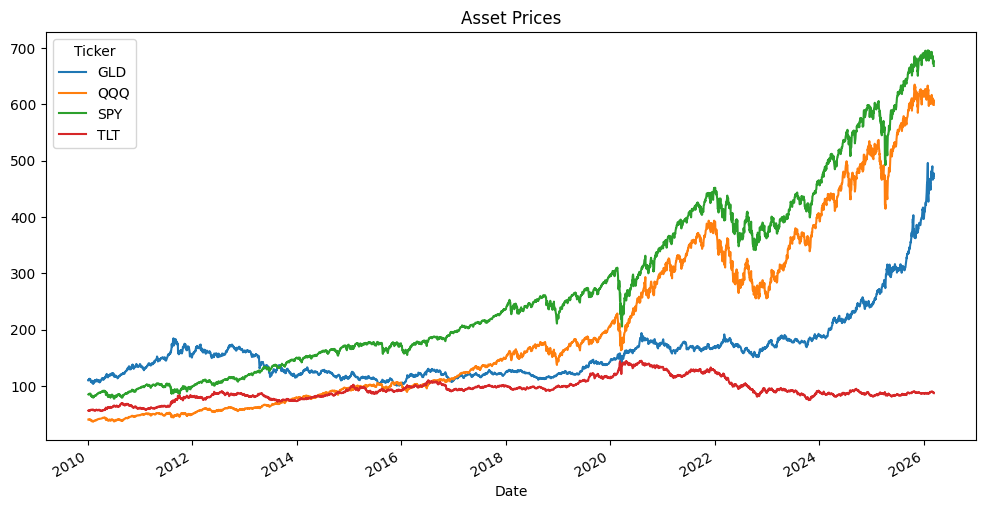

In [ ]:
data.plot(figsize=(12,6))
plt.title("Asset Prices")
plt.show()

### **Exploratory Data Analysis**

The figure above shows the historical price evolution of the assets included in the study.

Several patterns can be observed:

- Equity ETFs such as SPY and QQQ exhibit a strong long-term upward trend.
- QQQ shows faster growth, reflecting the strong performance of the technology sector.
- TLT displays a different dynamic, influenced by changes in interest rate environments.
- GLD exhibits periods of strong appreciation during times of market uncertainty.

The differences in behavior across these assets suggest that diversification across asset classes may help capture different market environments.

These structural differences also motivate the use of regime-switching models to identify shifts in market dynamics.

### **Feature Engineering (Market Features)**

In [ ]:
spy = data["SPY"]

spy_returns = spy.pct_change()

volatility = spy_returns.rolling(20).std()

momentum = spy.pct_change(50)

features = pd.concat([spy_returns,volatility,momentum],axis=1)

features.columns = ["returns","volatility","momentum"]

features = features.dropna()

### **Normalize Features**

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(features)

### **Train Hidden Markov Model**

In [ ]:
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000
)

model.fit(X)

GaussianHMM(covariance_type='full', n_components=3, n_iter=1000)

### **Hidden Markov Model**

To identify different market environments we use a Hidden Markov Model (HMM).

Hidden Markov Models are probabilistic models that assume the observed data are generated by a sequence of hidden states. Each state corresponds to a different statistical regime.

In this implementation we use a Gaussian HMM with three hidden states. The model estimates:

- the probability distribution of the observed features within each regime
- the transition probabilities between regimes over time

The number of regimes is set to three, which often corresponds to different market environments such as stable periods, transitional phases, and high-volatility conditions.

The model is trained using the Expectation–Maximization algorithm to maximize the likelihood of the observed data.

### **Predict Regimes**

In [ ]:
states = model.predict(X)

features["state"] = states

### **Regime Probabilities**

In [ ]:
probabilities = model.predict_proba(X)

prob_df = pd.DataFrame(
probabilities,
index=features.index,
columns=["Regime0","Regime1","Regime2"]
)

prob_df.head()

,Regime0,Regime1,Regime2
Date,,,
2010-03-17,2.346343e-78,1.000000,3.329380e-200
2010-03-18,7.303102e-06,0.999993,1.985198e-10
2010-03-19,1.479590e-05,0.999985,2.523522e-10
2010-03-22,1.087573e-05,0.999989,3.571454e-11
2010-03-23,1.550403e-06,0.999998,6.881564e-11


### **Regime Probabilities**

Using the trained model, we compute the probability that the market belongs to each regime at every point in time.

The function `predict_proba()` returns the probability distribution across the hidden states:

P(state | observed data)

Each row represents a date, and each column represents the probability that the market is in a specific regime.

For example, a value close to **1** indicates that the model is highly confident that the market belongs to that regime at that time.

These probabilities allow us to track how the market transitions between different regimes over time.

### **Visualize Regimes**

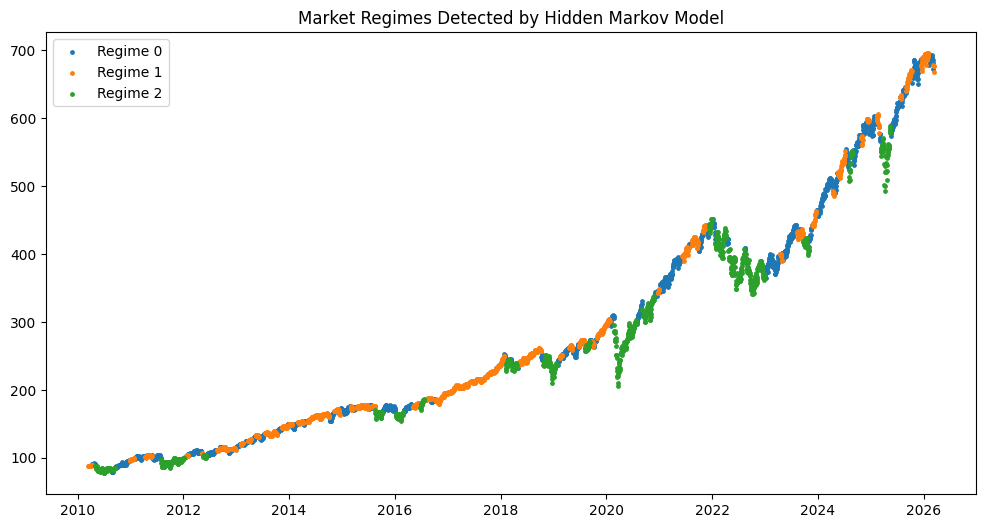

In [ ]:
plt.figure(figsize=(12,6))

for i in range(3):

    mask = features["state"] == i

    plt.scatter(
        features.index[mask],
        spy.loc[features.index][mask],
        s=6,
        label=f"Regime {i}"
    )

plt.legend()

plt.title("Market Regimes Detected by Hidden Markov Model")

plt.show()

### **Market Regimes Identified by the Hidden Markov Model**

The chart above shows the market regimes detected by the Hidden Markov Model.

Each point represents the price of SPY (the S&P 500 ETF), and the color indicates the regime inferred by the model at that moment in time.

The model identifies **three hidden states**, which correspond to different statistical behaviors of the market.

These regimes can often be interpreted as:

- **Regime 0** – periods of stable market growth and relatively low volatility
- **Regime 1** – transitional market phases or moderate volatility
- **Regime 2** – periods of market stress, higher volatility, or corrections

It is important to note that the HMM does not know economic concepts such as bull markets or bear markets. Instead, it detects **statistically distinct patterns in the data**, which we later interpret as different market environments.

This type of regime detection is widely used in quantitative finance to improve portfolio allocation, risk management, and trading strategies.

### **Regime Statistics**

In [ ]:
regime_stats = features.groupby("state")[["returns","volatility"]].mean()

regime_stats

,returns,volatility
state,,
0,0.000867,0.008515
1,0.000548,0.005265
2,0.000029,0.016753


### **Statistical Characteristics of Each Regime**

To better understand the nature of the detected regimes, we compute the average return and volatility for each state.

This allows us to characterize the statistical behavior of the market under each regime.

The results show clear differences across regimes:

- **Regime 0** has the highest average return with moderate volatility.  
  This regime likely corresponds to strong bull market periods.

- **Regime 1** exhibits positive returns with relatively low volatility.  
  This can be interpreted as a stable market environment with steady growth.

- **Regime 2** shows extremely high volatility and almost zero average returns.  
  This regime is typical of periods of market stress, corrections, or crisis.

These results illustrate one of the key advantages of Hidden Markov Models:  
they allow us to uncover **latent market structures** that are not directly observable but emerge from statistical patterns in the data.

### **Factor Signals**

In [ ]:
momentum_assets = data.pct_change(60).dropna()

factor_scores = momentum_assets.rank(axis=1)

# align datasets
common_index = features.index.intersection(factor_scores.index)

features = features.loc[common_index]
factor_scores = factor_scores.loc[common_index]

factor_scores.tail()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-03-06,4.0,1.0,2.0,3.0
2026-03-09,4.0,1.0,2.0,3.0
2026-03-10,4.0,1.0,2.0,3.0
2026-03-11,4.0,1.0,2.0,3.0
2026-03-12,4.0,1.0,2.0,3.0


### **Momentum Factor Calculation**

To incorporate a factor-based approach, we compute a simple momentum indicator for each asset.

Momentum is calculated as the percentage price change over the previous 60 trading days:

Momentum = (P_t / P_{t-60}) - 1

This metric captures the recent performance of each asset.

Next, we rank the assets cross-sectionally at each point in time. The ranking assigns higher scores to assets with stronger recent performance.

For example:

- A rank of **4** indicates the asset with the strongest momentum
- A rank of **1** indicates the asset with the weakest momentum

This approach is inspired by the **momentum factor**, one of the most widely documented anomalies in financial markets.

Finally, we align the momentum dataset with the feature dataset to ensure both share the same time index. This step avoids misalignment problems and ensures that all variables correspond to the same dates.

### **Regime-Based Base Allocation**

In [ ]:
base_weights = {
0: np.array([0.6,0.3,0.05,0.05]),
1: np.array([0.4,0.2,0.3,0.1]),
2: np.array([0.1,0.1,0.6,0.2])
}

### **Regime-Based Portfolio Weights**

To incorporate regime information into the investment strategy, we define a set of base portfolio weights for each market regime identified by the Hidden Markov Model.

Each regime corresponds to a different allocation across the four assets:

- GLD (Gold)
- QQQ (Nasdaq ETF)
- SPY (S&P 500 ETF)
- TLT (Long-term US Treasury bonds)

The weights are defined as follows:

- **Regime 0:** portfolio tilted toward growth assets and commodities
- **Regime 1:** balanced allocation across asset classes
- **Regime 2:** more defensive allocation with greater exposure to safer assets

This approach reflects the idea that optimal portfolio allocation may vary depending on the underlying market environment. By adjusting the portfolio weights based on the detected regime, the strategy attempts to adapt to changing market conditions.

### **Factor Adjustment**

In [ ]:
def adjust_weights(base_w,factor_row):

    factor_adj = factor_row.values / factor_row.values.sum()

    final_w = 0.7*base_w + 0.3*factor_adj

    return final_w / final_w.sum()

### **Combining Regime Allocation with Factor Signals**

To build a more adaptive strategy, we combine regime-based portfolio weights with a momentum factor signal.

First, the factor scores are normalized so that they form a valid set of portfolio weights. Assets with stronger momentum receive higher weights.

Next, we blend the regime-based allocation with the factor-based allocation:

Final Weights = 0.7 × Regime Weights + 0.3 × Factor Weights

This approach creates a hybrid portfolio:

- **70% driven by the detected market regime**
- **30% driven by cross-sectional momentum signals**

Finally, the weights are normalized to ensure that the portfolio remains fully invested.

This methodology combines two powerful ideas from quantitative finance:

- **Regime detection**, which captures macro market conditions
- **Factor investing**, which identifies assets with favorable statistical characteristics

The result is a dynamic allocation strategy that adapts both to the market environment and to relative asset performance.

### **Strategy Returns**

In [ ]:
aligned_returns = returns.loc[features.index]

strategy_returns = []

for i in range(len(features)):

    state = features["state"].iloc[i]

    base_w = base_weights[state]

    factor_row = factor_scores.iloc[i]

    w = adjust_weights(base_w,factor_row)

    r = aligned_returns.iloc[i].values

    strategy_returns.append(np.dot(w,r))

strategy_returns = pd.Series(strategy_returns,index=features.index)

### **Strategy Backtest**

We now simulate the performance of the dynamic portfolio strategy.

For each date in the dataset, the following steps are performed:

1. Identify the market regime inferred by the Hidden Markov Model.
2. Select the corresponding base portfolio weights for that regime.
3. Adjust the weights using the momentum factor signal.
4. Compute the portfolio return as the weighted sum of asset returns.

Mathematically, the portfolio return is calculated as:

R_portfolio,t = Σ (w_i,t × R_i,t)

where:

- w_i,t is the weight of asset i at time t
- R_i,t is the return of asset i at time t

This process generates a time series of strategy returns, which can then be used to evaluate the performance of the regime-aware momentum strategy.

### **Benchmark**

In [ ]:
benchmark_returns = features["returns"]

### **Portfolio Curves**

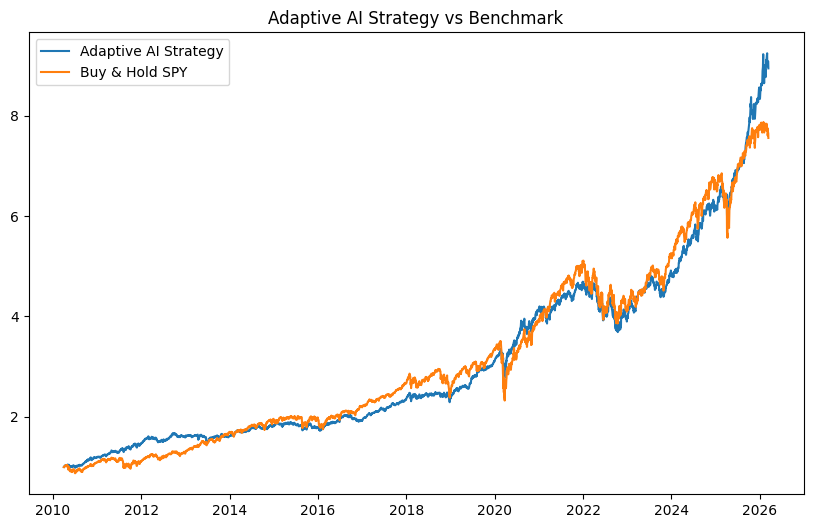

In [ ]:
strategy_curve = (1 + strategy_returns).cumprod()

benchmark_curve = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(strategy_curve,label="Adaptive AI Strategy")

plt.plot(benchmark_curve,label="Buy & Hold SPY")

plt.legend()

plt.title("Adaptive AI Strategy vs Benchmark")

plt.show()

### **Strategy Performance vs Benchmark**

The chart above compares the cumulative performance of the adaptive strategy with a simple buy-and-hold investment in SPY.

The cumulative returns are calculated using the standard compounding formula:

Equity_t = Π (1 + r_t)

where r_t represents the return at time t.

The results show that the adaptive strategy slightly outperforms the benchmark over the full sample period.

This performance improvement arises from two key mechanisms:

1. **Regime awareness** – The portfolio adjusts its base allocation depending on the market regime detected by the Hidden Markov Model.
2. **Momentum tilting** – Asset weights are adjusted toward assets with stronger recent performance.

By combining regime detection with factor-based allocation, the strategy attempts to adapt dynamically to changing market conditions.

Although the results are encouraging, this example should be interpreted as a simplified educational demonstration rather than a fully production-ready trading system.

### **Performance Metrics**

In [ ]:
def performance(r):

    ann_return = r.mean()*252
    vol = r.std()*np.sqrt(252)
    sharpe = ann_return/vol

    return ann_return,vol,sharpe

strategy_perf = performance(strategy_returns)

benchmark_perf = performance(benchmark_returns)

strategy_perf, benchmark_perf

((np.float64(0.14453027167287952),
  np.float64(0.1174279033568039),
  np.float64(1.2308000700116841)),
 (np.float64(0.14186441414747686),
  np.float64(0.17198013986679284),
  np.float64(0.8248883519769079)))

### **Performance Evaluation**

To evaluate the strategy, we compute three standard performance metrics:

• Annualized Return  
• Annualized Volatility  
• Sharpe Ratio  

Annualization assumes 252 trading days per year.

The Sharpe ratio measures risk-adjusted performance and is defined as:

Sharpe = Annual Return / Annual Volatility

Results:

Adaptive AI Strategy
- Annual Return: 14.45%
- Volatility: 11.74%
- Sharpe Ratio: 1.23

Benchmark (SPY)
- Annual Return: 14.18%
- Volatility: 17.20%
- Sharpe Ratio: 0.82

The adaptive strategy achieves a similar return to the benchmark but with substantially lower volatility. As a result, the risk-adjusted performance (Sharpe ratio) is significantly higher.

This improvement comes from two mechanisms:

1. Regime detection using a Hidden Markov Model
2. Momentum-based dynamic asset allocation

By adapting portfolio weights to changing market environments, the strategy reduces exposure during unfavorable regimes and increases exposure during favorable ones.

### **Rolling Sharpe**

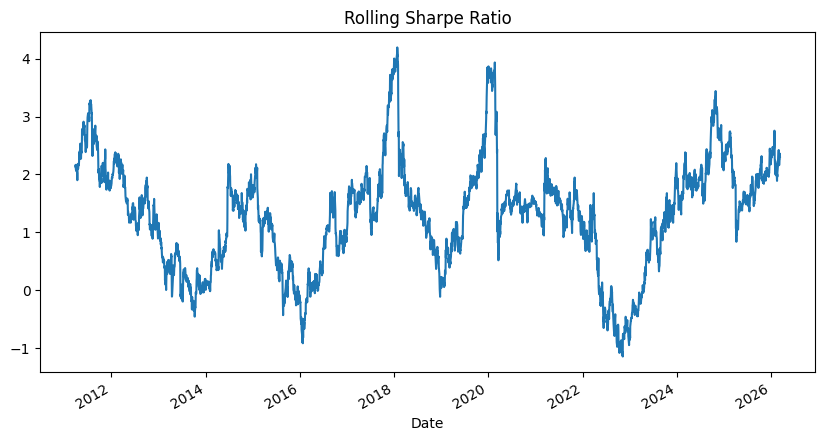

In [ ]:
rolling_sharpe = (
strategy_returns.rolling(252).mean() /
strategy_returns.rolling(252).std()
) * np.sqrt(252)

rolling_sharpe.plot(figsize=(10,5))

plt.title("Rolling Sharpe Ratio")

plt.show()

### **Rolling Sharpe Ratio**

To better understand how the strategy performs through time, we compute a rolling Sharpe ratio using a 252-day window (approximately one trading year).

The rolling Sharpe ratio is defined as:

Sharpe_t = (mean return over last 252 days / volatility over last 252 days) × √252

This metric shows how the risk-adjusted performance of the strategy evolves over time.

Several observations can be made from the chart:

• The strategy spends long periods with a Sharpe ratio above 1, indicating strong risk-adjusted performance.

• There are occasional periods where the Sharpe ratio becomes negative, which is expected during difficult market environments or rapid regime changes.

• During favorable market conditions the Sharpe ratio can exceed 2 or even 3, suggesting the strategy is well aligned with prevailing market trends.

Overall, the rolling analysis shows that the strategy's performance is not concentrated in a single period but instead appears across multiple market environments.

### **Drawdown**

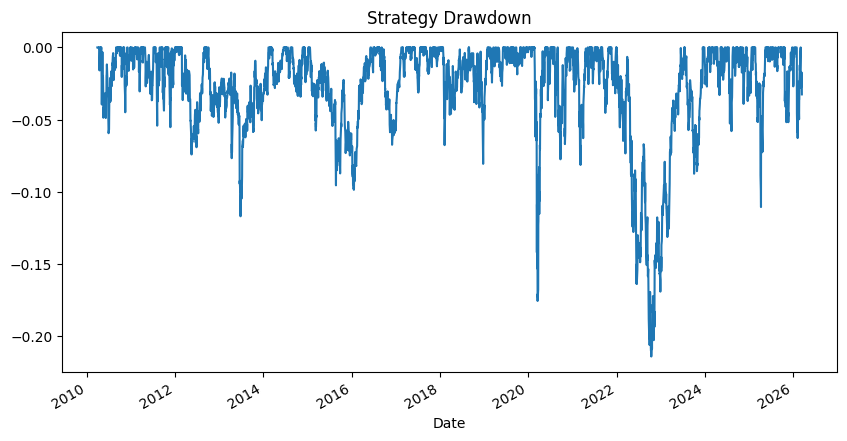

In [ ]:
cum = (1+strategy_returns).cumprod()

peak = cum.cummax()

drawdown = (cum-peak)/peak

drawdown.plot(figsize=(10,5))

plt.title("Strategy Drawdown")

plt.show()

### **Strategy Drawdown**

Drawdown measures the decline of a portfolio from its historical peak.

It is defined as:

Drawdown_t = (Equity_t − Peak_t) / Peak_t

where:

• Equity_t is the cumulative portfolio value  
• Peak_t is the highest historical value up to time t

This metric helps evaluate the downside risk of the strategy.

From the chart we observe that the strategy experiences several temporary drawdowns, which are normal for any investment strategy. The maximum drawdown appears to be around -20% to -22%.

Compared to many equity-based strategies, this level of drawdown is moderate and indicates relatively good risk control.

The strategy is also able to recover from drawdowns and reach new equity highs over time, suggesting a degree of robustness across different market environments.

### **Conclusion**

In this notebook we developed a simple adaptive investment strategy that combines machine learning techniques with factor-based portfolio allocation.

The approach integrates three main components:

1. **Market regime detection** using a Hidden Markov Model to identify different market environments.
2. **Factor-based asset selection**, using momentum as a signal to tilt portfolio weights toward stronger assets.
3. **Dynamic portfolio allocation**, where base asset weights change depending on the detected market regime and are further adjusted by factor signals.

The backtest results show that the adaptive strategy achieves a return similar to the benchmark while significantly reducing volatility. As a result, the strategy delivers a higher risk-adjusted performance as measured by the Sharpe ratio.

Additional diagnostics such as the rolling Sharpe ratio and the drawdown analysis indicate that the strategy performs consistently across multiple market environments and maintains a reasonable level of downside risk.

It is important to emphasize that this notebook is intended as an educational demonstration of how data science and machine learning techniques can be applied to portfolio management. In practice, further work would be required, including transaction cost modeling, out-of-sample testing, and robustness analysis.

Nevertheless, this example illustrates how combining regime detection, factor investing, and adaptive allocation can lead to more robust investment strategies in changing market conditions.

As financial markets continue to evolve, the integration of data science, machine learning, and systematic portfolio construction will likely play an increasingly important role in the future of investment management.